# 8 기하학 처리
영상 처리에서 기하학 처리는 영상 내에 있는 기하학적 대상의 공간적 배치를 변경하는 과정이다. 이 변환은 크게 회전(Rotation), 크기 변경(Scaling), 평행 이동(Translation) 등이 있고 이 세가지 변환을 RST 변환이라고 한다.  

## 8.1 사상
기하학적 처리의 기본은 화소들의 배치를 변경하는 것이다. 그래서 입력 영상의 새롭게 배치될 해당 목적 영상의 좌표를 찾아서 화소 값을 옮기는 과정이다.  
* 순방향 사상  
입력 영상의 좌표를 중심으로 목적 영상의 좌표를 계산하여 화소의 위치를 변환하는 방식이다. 이 방식은 일반적으로 입력과 목적이 크기가 같을 때 유용하게 사용되고 크기가 다르면 홀이나 오버랩의 문제가 발생한다.  
    * 홀: 입력 영상의 좌표들로 목적 영상의 좌표를 만드는 과정에서 사상 되지 않은 원소, 확대나 회전시 발생
    * 오버랩: 입력의 여러 화소들이 목적의 한 화소로 사상되는 것, 축소시 발생
* 역방향 사상  
순방향의 반대 방향 사상이다. 홀이나 오버랩은 발생하지 않지만 입력 영상의 한 화소를 목적 영상의 여러 화소에서 사용하면 결과 영상의 품질이 떨어진다. 이러한 문제를 보간법이다.  

## 8.2 크기 변경 (확대/축소)
크기 변경은 입력 영상의 가로, 세로로 크기를 변경해서 목적 영상을 만드는 방법  
크기 변경 하는 방법은 비율을 이용해서 수행할 수 있다. 비율을 지정하여 입력 영상의 좌표에 스칼라 곱하면 계산할 수 있다. 그리고 목적 영상의 크기를 지정해서 변경할 수 있다. 입력영상/목적영상 크리고 비율을 계산하여 전자처럼 곱하여 계산한다.


In [4]:
import numpy as np, cv2, time
import matplotlib.pyplot as plt

In [9]:
def scaling(img, size):
    dst = np.zeros(size[::-1], img.dtype)
    ratioY, ratioX = np.divide(size[::-1], img.shape[:2])
    y = np.arange(0, img.shape[0], 1)
    x = np.arange(0, img.shape[1], 1)
    y, x = np.meshgrid(y, x)
    i, j = np.int32(y * ratioY), np.int32(x * ratioX)
    dst[i, j] = img[y, x]
    return dst

def scaling2(img, size):
    dst = np.zeros(size[::-1], img.dtype)
    ratioY, ratioX = np.divide(size[::-1], img.shape[:2])
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            i, j = int(y * ratioY), int(x * ratioX)
            dst[i, j] = img[y, x]
    
    return dst

def time_check(func, img, size, title):
    start_time = time.perf_counter()
    ret_img = func(img, size)
    elapsed = (time.perf_counter() - start_time) * 1000
    print(title, "elapsed time: %0.2f ms" % elapsed)
    return ret_img

point mat elapsed time: 117.52 ms
loop elapsed time: 2893.71 ms


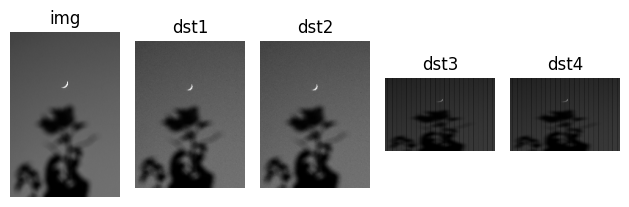

In [17]:
img = cv2.imread("../images/moon.jpg", cv2.IMREAD_GRAYSCALE)

dst1 = scaling(img, (150, 200))
dst2 = scaling2(img, (150, 200))

x, y = int(img.shape[0] * 1.4), int(img.shape[1] * 1.4)
dst3 = time_check(scaling, img, (np.int32(x), np.int32(y)), "point mat")
dst4 = time_check(scaling2, img, (x, y), "loop")

titles = ['img', 'dst1', 'dst2', 'dst3', 'dst4']
fig, axs = plt.subplots(nrows=1, ncols=5)

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 8.3 보간
순방향 사상으로 확대하면 홀이 많이 발생하게 된다. 이러한 문제는 역방향 사상을 통해서 홀의 화소들을 입력 영상에서 찾아 목적 영상의 화소에 대입함으로써 목적 영상의 화질을 유지할 수 있다. 그리고 오버랩되지 않게 화소들을 배치하여 목적영상을 만드는 기법을 보간법이라고 한다.

## 8.3.1 최근접 이웃 보간법
목적 영상을 만드는 과정에서 홀이 되어 화소값을 할당 받지 못한 위치에 값을 찾을 때, 그 위치에 가장 가깝게 이웃한 입력 영상의 화소값을 가져오는 방법이다.  
목적 화소의 좌표를 반올림하는 하여 홀을 채울 수 있어 영상의 품질을 높일 수 있지만 확대 비율이 커지면 경계선이나 모서리 부분에서 계단 현상이 나타날 수 있다.

In [13]:
def scaling_nearest(img, size):
    dst = np.zeros(size[::-1], img.dtype)
    ratioY, ratioX  = np.divide(size[::-1], img.shape[:2])
    i = np.arange(0, size[1], 1)
    j = np.arange(0, size[0], 1)
    i, j = np.meshgrid(i, j)
    y, x = np.int32(i / ratioY), np.int32(j / ratioX)
    dst[i, j] = img[y, x]

    return dst

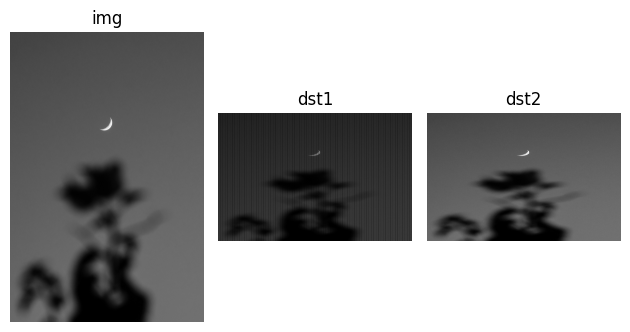

In [14]:
img = cv2.imread("../images/moon.jpg", cv2.IMREAD_GRAYSCALE)

toX = np.int32(img.shape[0] * 1.4)
toY = np.int32(img.shape[1] * 1.4)
dst1 = scaling(img, (toX, toY))
dst2 = scaling_nearest(img, (toX, toY))

titles = ['img', 'dst1', 'dst2']
fig, axs = plt.subplots(nrows=1, ncols=3)

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 8.3.2 양선형 보간법
최근접 이웃 보간법은 계단 현상이 나타나는데 이를 보완하는 방법이 양선형 보간법이다.  
여기서 선형은 직선의 방정식을 의미하는 것으로 두 개의 화소 값을 알면 직선의 방정식을 구할 수 있다 그래서 이 직선 위에 있는 화소의 값을 직선의 방정식을 이용해서 계산할 수 있다. 그런데 이 과정을 두 번 하기 때문에 양선형이 된 것이다.  
더 자세하게 설명하면 어떤 목적 영상 화소를 역변환으로 계산해 가장 가까운 위치에 있는 입력 영상의 4개 화소(반시계 방향으로 ABCD)를 가져온다. 이때 AB, CD 묶어서 두 화소를 잇는 직선을 구성하고 그 직선에서 목적 영상 화소의 좌표로 직선에서의 값을 둘 다 찾는다 그리고 그 점을 이으면 목적 영상 화소 좌표와 AB, CD를 지나는 직선을 구할 수 있다 이를 이용해서 목적 영상 화소 값을 정한다. 처음의 AB CD를 구하는 과정을 하나로 보고 나머지를 합하여 양선형 보간이라고 하는 것이다.

In [35]:
def bilinear_value(img, pt):
    x, y = np.int32(pt)
    if x >= img.shape[1] - 1: x -= 2
    if y >= img.shape[0] - 1: y -= 2
    
    p1 = float(img[y, x])
    p2 = float(img[y, x + 1])
    p3 = float(img[y + 1, x])
    p4 = float(img[y + 1, x + 1])

    alpha, beta = pt[1] - y, pt[0] - x
    m1 = p1 + alpha * (p3 - p1)
    m2 = p2 + alpha * (p4 - p2)
    p = m1 + beta * (m2 - m1)
    return np.clip(p, 0, 255)

def scaling_blinear(img, size):
    ratioY, ratioX = np.divide(size[::-1], img.shape[:2])

    dst = [[bilinear_value(img, (j/ratioX, i/ratioY)) for j in range(size[0])] for i in range(size[1])]

    return np.array(dst, img.dtype)

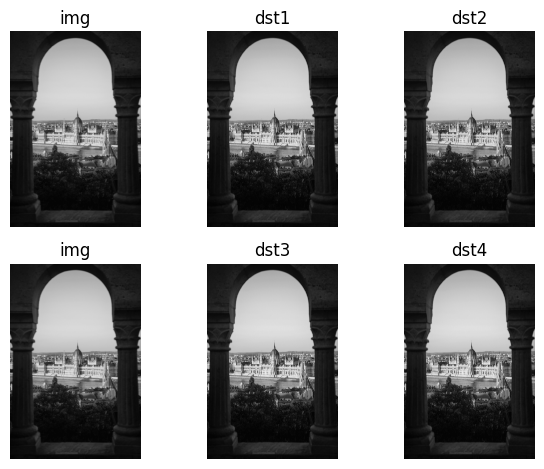

In [37]:
img = cv2.imread("../images/castle.jpg", cv2.IMREAD_GRAYSCALE)

toX = int(img.shape[1] * 1.4)
toY = int(img.shape[0] * 1.4)
size = (toX, toY)

dst1 = scaling_blinear(img, (toX, toY))
dst2 = scaling_nearest(img, (toX, toY))
dst3 = cv2.resize(img, size, 0, 0, cv2.INTER_LINEAR)
dst4 = cv2.resize(img, size, 0, 0, cv2.INTER_NEAREST)

titles = ['img', 'dst1', 'dst2', 'img', 'dst3', 'dst4']
fig, axs = plt.subplots(nrows=2, ncols=3)

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 8.4 평행이동
영상의 좌상단은 원점 좌표이다 평행이동이란 영상의 원점인 좌상단을 기준으로 모든 화소를 동일하게 가로 방향과 세로 방향으로 옮기는 것을 말한다.  

In [24]:
def contain(p, shape):
    return 0 <= p[0] < shape[0] and 0 <= p[1] < shape[1]

def translate(img, pt):
    dst = np.zeros(img.shape, img.dtype)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            x, y = np.subtract((j, i), pt)
            if contain((y, x), img.shape):
                dst[i, j] = img[y, x]

    return dst

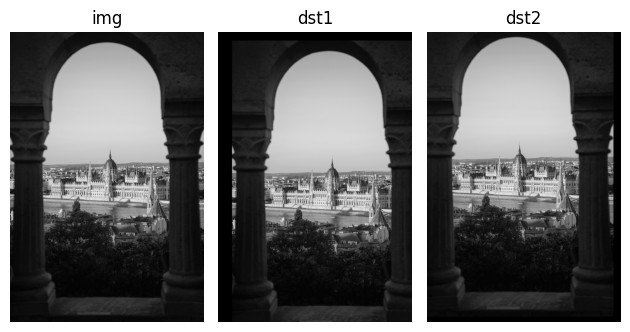

In [26]:
img = cv2.imread("../images/castle.jpg", cv2.IMREAD_GRAYSCALE)

dst1 = translate(img, (130, 80))
dst2 = translate(img, (-70, -50))

titles = ['img', 'dst1', 'dst2']
fig, axs = plt.subplots(nrows=1, ncols=3)

for ax, title in zip(axs.flat, titles):
    ax.imshow(eval(title), cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 8.5 회전
입력영상의 모든 화소를 영상의 원점을 기준으로 원하는 각도만큼 모든 화소를 영상의 원점을 기준으로 원하는 각도만큼 모든 화소에 대해서 회전 변환을 시키는 것  
* 순방향
x', y' = ((cosu , -sinu), (sinu, cosu))(x, y) , 극좌표계를 생각해보면 알 수 있다.  
* 역방향
x', y' = ((cosu , sinu), (-sinu, cosu))(x, y) , 이 또한 -u만큼 회전시킨 극좌표계를 생각 해보면 된다.  